In [1]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, coo_matrix
from sklearn.metrics import mean_squared_error, average_precision_score
import matplotlib.pyplot as plt

In [2]:
data_test = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/test_interactions.csv')
data_train = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/train_interactions.csv')

In [3]:
class ALS:
    def __init__(self, n_factors=10, alpha=40, regularization=0.1, iterations=15):
        """
        Инициализация ALS модели
        
        Parameters:
        - n_factors: количество латентных факторов
        - alpha: параметр уверенности для неявной обратной связи
        - regularization: коэффициент регуляризации (lambda)
        - iterations: количество итераций обучения
        """
        self.n_factors = n_factors
        self.alpha = alpha
        self.regularization = regularization
        self.iterations = iterations
        self.user_factors = None
        self.item_factors = None
        self.loss_history = []
    
    def fit(self, ratings):
        """
        Обучение ALS модели
        
        Parameters:
        - ratings: scipy sparse matrix в формате (users × items)
        """
        n_users, n_items = ratings.shape
        
        # Инициализация матриц факторов
        self.user_factors = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.item_factors = np.random.normal(0, 0.1, (n_items, self.n_factors))
        
        print("Начинаем обучение ALS...")
        
        for iteration in range(self.iterations):
            # Шаг 1: Фиксируем item factors, обновляем user factors
            for u in range(n_users):
                # Получаем индексы и значения оценок пользователя
                user_ratings = ratings[u].toarray().flatten()
                rated_items = np.where(user_ratings > 0)[0]
                
                if len(rated_items) > 0:
                    # Вычисляем уверенности для неявной обратной связи
                    confidence = 1 + self.alpha * user_ratings[rated_items]
                    
                    # Матрица item factors для оцененных items
                    Y = self.item_factors[rated_items]
                    
                    # Вычисляем матрицу A и вектор b
                    C = np.diag(confidence)
                    A = Y.T @ C @ Y + self.regularization * np.eye(self.n_factors)
                    b = Y.T @ confidence
                    
                    # Решаем линейную систему
                    self.user_factors[u] = np.linalg.solve(A, b)
            
            # Шаг 2: Фиксируем user factors, обновляем item factors
            for i in range(n_items):
                # Получаем индексы и значения оценок для item
                item_ratings = ratings[:, i].toarray().flatten()
                rating_users = np.where(item_ratings > 0)[0]
                
                if len(rating_users) > 0:
                    # Вычисляем уверенности
                    confidence = 1 + self.alpha * item_ratings[rating_users]
                    
                    # Матрица user factors для оценивших пользователей
                    X = self.user_factors[rating_users]
                    
                    # Вычисляем матрицу A и вектор b
                    C = np.diag(confidence)
                    A = X.T @ C @ X + self.regularization * np.eye(self.n_factors)
                    b = X.T @ confidence
                    
                    # Решаем линейную систему
                    self.item_factors[i] = np.linalg.solve(A, b)
            
            # Вычисляем loss
            loss = self._compute_loss(ratings)
            self.loss_history.append(loss)
            print(f"Итерация {iteration + 1}/{self.iterations}, Loss: {loss:.4f}")
    
    def _compute_loss(self, ratings):
        """Вычисление функции потерь"""
        loss = 0
        n_users, n_items = ratings.shape
        
        for u in range(n_users):
            for i in range(n_items):
                if ratings[u, i] > 0:
                    prediction = self.user_factors[u] @ self.item_factors[i]
                    confidence = 1 + self.alpha * ratings[u, i]
                    error = confidence - prediction
                    loss += error ** 2
        
        # Добавляем регуляризацию
        reg_loss = self.regularization * (
            np.sum(self.user_factors ** 2) + np.sum(self.item_factors ** 2)
        )
        
        return loss + reg_loss
    
    def predict(self, user_id, item_id):
        """Предсказание оценки"""
        return self.user_factors[user_id] @ self.item_factors[item_id]
    
    def recommend(self, user_id, n_recommendations=10):
        """Рекомендации для пользователя"""
        user_vector = self.user_factors[user_id]
        scores = user_vector @ self.item_factors.T
        top_items = np.argsort(scores)[::-1][:n_recommendations]
        return top_items, scores[top_items]
    
    def plot_loss(self):
        """Визуализация истории потерь"""
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history, marker='o')
        plt.title('История обучения ALS')
        plt.xlabel('Итерация')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()

In [4]:
def precision(recommended_list, bought_list):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(bought_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    return precision


def precision_at_k(recommended_list, bought_list, k=5):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    bought_list = bought_list 
    recommended_list = recommended_list[:k]
    
    flags = np.isin(bought_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    
    return precision

def ap_k(recommended_list, bought_list, k=5):
    
    bought_list = np.array(bought_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(recommended_list, bought_list)
    
    if sum(flags) == 0:
        return 0
    
    sum_ = 0
    for i in range(0, k-1):
        if flags[i] == True:
            p_k = precision_at_k(recommended_list, bought_list, k=i+1)
            sum_ += p_k
            
    result = sum_ / sum(flags)
    
    return result

def map_k(recommended_list, bought_list, k=5, u=1):
    
    # your_code
    if u == 1:
        return ap_k(recommended_list[u-1], bought_list[u-1], k=5)
    
    sum = 0
    for i in range(0, u):
        ap_k_map = ap_k(recommended_list[i], bought_list[i], k=5)
        sum += ap_k_map

    result = sum / u
    
    return result

In [5]:
def create_matrix(df, user_col='user_id', item_col='item_id', 
                           value_col='watched_pct'):

    unique_users = sorted(set(df[user_col]))
    unique_items = sorted(set(df[item_col]))

    user_to_index = {user: idx for idx, user in enumerate(unique_users)}
    item_to_index = {item: idx for idx, item in enumerate(unique_items)}

    index_to_user = {idx: user for user, idx in user_to_index.items()}
    index_to_item = {idx: item for item, idx in item_to_index.items()}

    n_users = len(unique_users)
    n_items = len(unique_items)

    user_indices = [user_to_index[u] for u in df[user_col]]
    item_indices = [item_to_index[i] for i in df[item_col]]

    sparse_matrix = csr_matrix((df[value_col], (user_indices, item_indices)), shape=(n_users, n_items))
    
    matrix_df = pd.DataFrame.sparse.from_spmatrix(
        sparse_matrix,
        index=unique_users,
        columns=unique_items
    )
    
    return matrix_df, sparse_matrix, index_to_user, index_to_item, user_to_index, item_to_index 

train_df, train_matrix, index_to_user_train, index_to_item_train, user_to_index_train, item_to_index_train = create_matrix(
    data_train, user_col='user_id', item_col='item_id', value_col='watched_pct'
)
test_df, test_matrix, index_to_user_test, index_to_item_test, user_to_index_test, item_to_index_test  = create_matrix(
    data_test, user_col='user_id', item_col='item_id', value_col='watched_pct'
)


Начинаем обучение ALS...
Итерация 1/40, Loss: 67705688.1823
Итерация 2/40, Loss: 67705644.3040
Итерация 3/40, Loss: 67705632.3818
Итерация 4/40, Loss: 67705625.7980
Итерация 5/40, Loss: 67705620.9644
Итерация 6/40, Loss: 67705616.9300
Итерация 7/40, Loss: 67705613.3454
Итерация 8/40, Loss: 67705610.0423
Итерация 9/40, Loss: 67705606.9341
Итерация 10/40, Loss: 67705603.9776
Итерация 11/40, Loss: 67705601.1503
Итерация 12/40, Loss: 67705598.4349
Итерация 13/40, Loss: 67705595.8178
Итерация 14/40, Loss: 67705593.2891
Итерация 15/40, Loss: 67705590.8410
Итерация 16/40, Loss: 67705588.4660
Итерация 17/40, Loss: 67705586.1587
Итерация 18/40, Loss: 67705583.9150
Итерация 19/40, Loss: 67705581.7319
Итерация 20/40, Loss: 67705579.6064
Итерация 21/40, Loss: 67705577.5359
Итерация 22/40, Loss: 67705575.5175
Итерация 23/40, Loss: 67705573.5484
Итерация 24/40, Loss: 67705571.6262
Итерация 25/40, Loss: 67705569.7480
Итерация 26/40, Loss: 67705567.9112
Итерация 27/40, Loss: 67705566.1139
Итерация 28

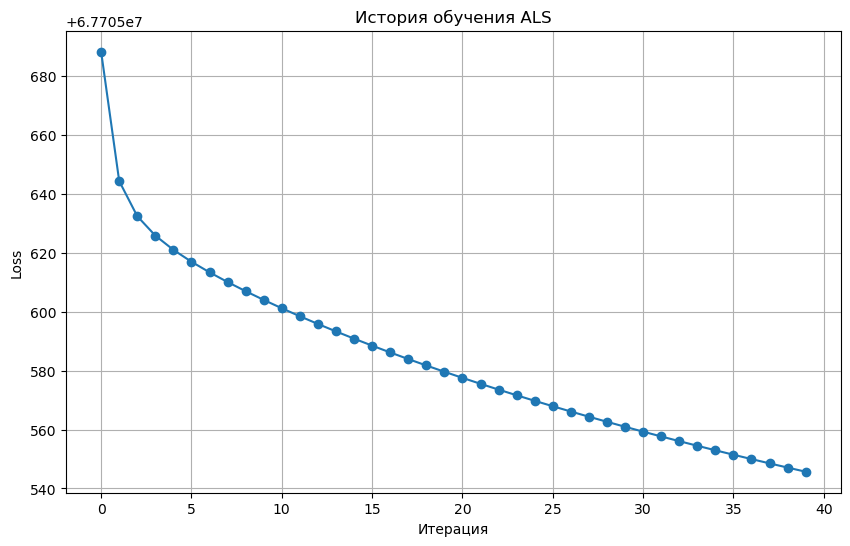


Оценка модели:
RMSE на тестовой выборке: 4.6084


In [100]:
print("\n" + "="*50)
als_model = ALS(
        n_factors=25,
        alpha=20,
        regularization=0.01,
        iterations=40
    )
    
# Обучение модели
als_model.fit(train_matrix)
    
# Визуализация процесса обучения
als_model.plot_loss()
    
# Оценка модели
print("\nОценка модели:")
    
# Предсказания на тестовой выборке
test_predictions = []
test_actual = []
    
for u in range(test_matrix.shape[0]):
    for i in range(test_matrix.shape[1]):
        if test_matrix[u, i] > 0:
                pred = als_model.predict(u, i)
                test_predictions.append(pred)
                test_actual.append(test_matrix[u, i])
    
# Вычисляем метрики
mse = mean_squared_error(test_actual, test_predictions)
rmse = np.sqrt(mse)


print(f"RMSE на тестовой выборке: {rmse:.4f}")

In [25]:
data_test_group = data_test.groupby(data_test['user_id'])['item_id'].unique().reset_index()
data_test_group.columns = ['user_id', 'item_id']
data_test_group

,user_id,item_id
0,2756,"[1247, 2925, 13325, 7793, 15399, 14488]"
1,4027,"[5732, 3838, 13159, 3349]"
2,4249,"[13483, 9778, 10125, 2865]"
3,4997,"[3190, 5732, 9194]"
4,5119,"[12356, 13849, 2596, 7968]"
...,...,...
1115,1093424,"[10636, 14488, 11118]"
1116,1094628,"[13543, 125, 10119, 9194, 3518]"
1117,1095418,"[14317, 2025, 1290]"
1118,1097444,"[13650, 12841, 12250, 2483]"


In [8]:
userids = data_test_group['user_id'].values
 
userids_test = np.arange(len(userids))

In [9]:
def recommendations__original_ids(user_matrix_index, item_recommendations):
    original_item_ids = [index_to_item_train[idx] for idx in item_recommendations]
    return user_matrix_index, original_item_ids

In [101]:
recommended = []
for i in range(len(userids_test)):
    recommended_items, scores = als_model.recommend(userids_test[i], n_recommendations=10)
    recommended.append({'item_id_pred': recommended_items})

result = pd.DataFrame(recommended, userids).reset_index()
result

,index,item_id_pred
0,2756,"[512, 675, 1393, 533, 1566, 498, 341, 92, 549,..."
1,4027,"[1231, 825, 1454, 1481, 224, 1926, 838, 1407, ..."
2,4249,"[899, 143, 34, 1784, 614, 853, 1766, 978, 1539..."
3,4997,"[907, 675, 1825, 1721, 1533, 1572, 211, 1476, ..."
4,5119,"[1721, 1077, 1157, 819, 907, 1095, 803, 1566, ..."
...,...,...
1115,1093424,"[1655, 681, 1486, 870, 378, 1575, 322, 1269, 6..."
1116,1094628,"[1155, 483, 767, 1025, 34, 1215, 838, 882, 412..."
1117,1095418,"[143, 1661, 13, 1863, 657, 1899, 506, 1948, 10..."
1118,1097444,"[900, 1077, 1105, 1617, 498, 1074, 1533, 1511,..."


In [102]:
recom =[]
for i in range(len(result)):
    user, recommend = recommendations__original_ids(userids[i], result['item_id_pred'][i])
    recom.append({'item_id_pred': recommend})

result_pred = pd.DataFrame(recom, userids).reset_index()
result_pred

,index,item_id_pred
0,2756,"[4239, 5693, 11749, 4436, 13099, 4151, 2954, 8..."
1,4027,"[10323, 6976, 12240, 12491, 1931, 16270, 7102,..."
2,4249,"[7571, 1287, 334, 14942, 5109, 7192, 14814, 82..."
3,4997,"[7626, 5693, 15297, 14431, 12849, 13159, 1844,..."
4,5119,"[14431, 9103, 9731, 6948, 7626, 9214, 6785, 13..."
...,...,...
1115,1093424,"[13865, 5755, 12502, 7331, 3293, 13185, 2816, ..."
1116,1094628,"[9728, 4034, 6440, 8636, 334, 10214, 7102, 741..."
1117,1095418,"[1287, 13915, 169, 15648, 5569, 16021, 4217, 1..."
1118,1097444,"[7582, 9103, 9298, 13500, 4151, 9070, 12849, 1..."


In [103]:
print('als_map_k =', map_k(result_pred['item_id_pred'], data_test_group['item_id'], k=10, u=len(data_test_group)))

als_map_k = 0.012760416666666668


In [70]:
random_user = np.random.choice(data_test['user_id'], replace=False)

In [30]:
items = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/data_original/items.csv')

In [71]:
rec_pred = result_pred.loc[result_pred['index']==random_user, 'item_id_pred'].iloc[0]
rec_test = data_test_group.loc[data_test_group['user_id']==random_user, 'item_id'].iloc[0]

pred_user_item = []
test_user_item = []

for i in range(len(rec_pred)):
    title_item = items.loc[items['item_id']==rec_pred[i], 'title'].iloc[0]
    pred_user_item.append(title_item)

for i in range(len(rec_test)):
    title_item = items.loc[items['item_id']==rec_test[i], 'title'].iloc[0]
    test_user_item.append(title_item)

print(f"Рекомендаций для пользователя {random_user}:") 
for i, (item) in enumerate(zip(pred_user_item)):
    print(f"{i+1}. {item}")
print('Test')
for i, (item) in enumerate(zip(test_user_item)):
    print(f"{i+1}. {item}")

Рекомендаций для пользователя 60711:
1. ('Холодное сердце II',)
2. ('Терминатор: Тёмные судьбы',)
3. ('Тайна Мунакра',)
4. ('Я сражаюсь с великанами',)
5. ('Избави нас от лукавого',)
6. ('Ральф',)
7. ('Люди Икс: Последняя битва',)
8. ('Сокровище Амазонки',)
9. ('Танки',)
10. ('1+1',)
Test
1. ('Призрачный гонщик 2',)
2. ('Пираты Карибского моря: Мертвецы не рассказывают сказки',)
3. ('Пираты карибского моря: На краю света',)
